In [2]:
#mini projet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement (remplacer par votre chemin de fichier)

df = pd.read_csv('C:/Users/hp/Desktop/DI_BOOTCAMP/week2/day4/dailyChallenge/Sample - Superstore.csv', encoding='latin1')

# Nettoyage de base
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Sales'] = pd.to_numeric(df['Sales'])
df['Profit'] = pd.to_numeric(df['Profit'])

Top 5 États (Ventes) :
 State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Name: Sales, dtype: float64

Comparaison NY vs CA :
                   Sales      Profit
State                              
California  457687.6315  76381.3871
New York    310876.2710  74038.5486


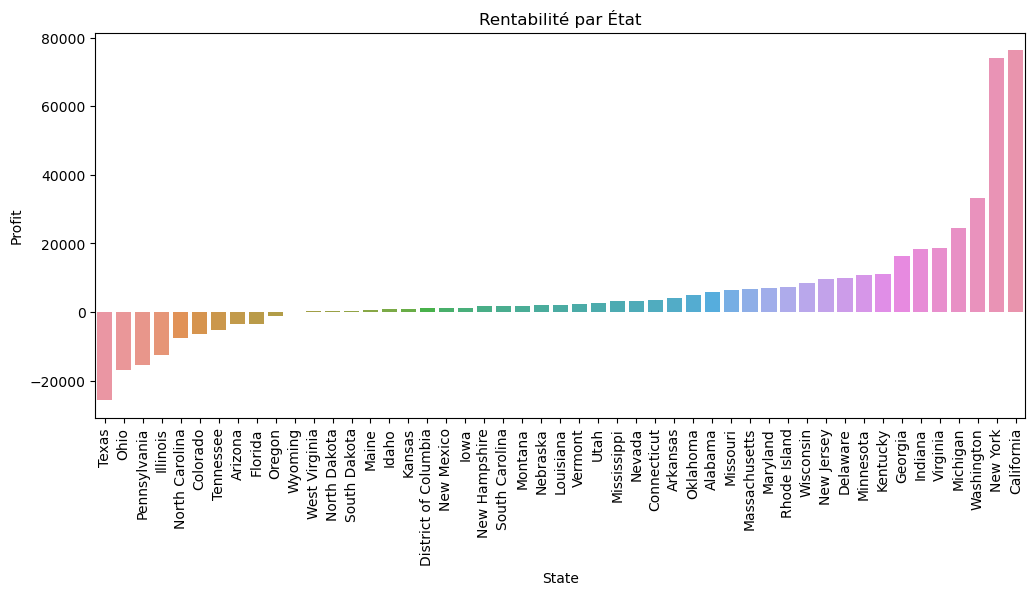

In [3]:
# Top 5 des États par ventes
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(5)
print("Top 5 États (Ventes) :\n", top_states)

# Comparaison NY vs Californie
ny_ca = df[df['State'].isin(['New York', 'California'])].groupby('State')[['Sales', 'Profit']].sum()
print("\nComparaison NY vs CA :\n", ny_ca)

# Visualisation des bénéfices par État (Différences de rentabilité)
plt.figure(figsize=(12, 5))
sns.barplot(data=df.groupby('State')['Profit'].sum().reset_index().sort_values(by='Profit'), x='State', y='Profit')
plt.xticks(rotation=90)
plt.title("Rentabilité par État")
plt.show()


In [4]:
top_cities_sales = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(20)
top_cities_profit = df.groupby('City')['Profit'].sum().sort_values(ascending=False).head(20)

# Analyse de la rentabilité des villes
# Note : Certaines villes du Top Ventes peuvent avoir des profits négatifs (Pertes)
cities_compare = df.groupby('City')[['Sales', 'Profit']].sum().loc[top_cities_sales.index]
print("Rentabilité des 20 premières villes en Ventes :\n", cities_compare)


Rentabilité des 20 premières villes en Ventes :
                      Sales      Profit
City                                  
New York City  256368.1610  62036.9837
Los Angeles    175851.3410  30440.7579
Seattle        119540.7420  29156.0967
San Francisco  112669.0920  17507.3854
Philadelphia   109077.0130 -13837.7674
Houston         64504.7604 -10153.5485
Chicago         48539.5410  -6654.5688
San Diego       47521.0290   6377.1960
Jacksonville    44713.1830  -2323.8350
Springfield     43054.3420   6200.6974
Detroit         42446.9440  13181.7908
Columbus        38706.2430   5897.1013
Newark          28576.1190   5793.7588
Columbia        25283.3240   5606.1167
Lafayette       25036.2000  10018.3876
Jackson         24963.8580   7581.6828
San Antonio     21843.5280  -7299.0502
Burlington      21668.0820  -3622.8772
Arlington       20214.5320   4169.6969
Dallas          20131.9322  -2846.5257


In [5]:
# Client star à NY (Plus haut profit)
client_ny = df[df['State'] == 'New York'].groupby('Customer Name')['Profit'].sum().sort_values(ascending=False).head(1)
print("Client exceptionnel à NY :", client_ny.index[0])

# Top 20 Clients globaux par ventes
top_20_clients_sales = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(20)


Client exceptionnel à NY : Tom Ashbrook


Loi de Pareto pour Sales : 20% des clients génèrent 48.07% des Sales.


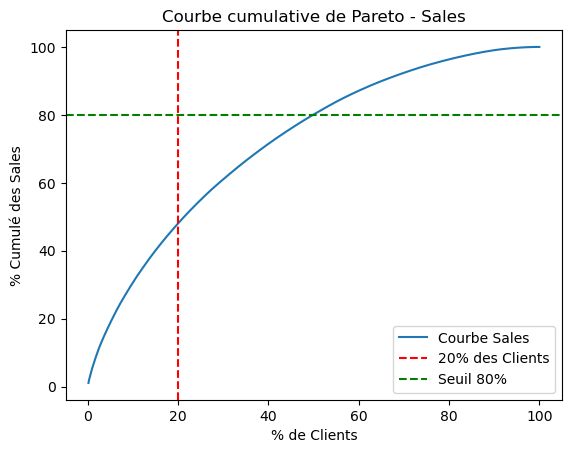

Loi de Pareto pour Profit : 20% des clients génèrent 57.44% des Profit.


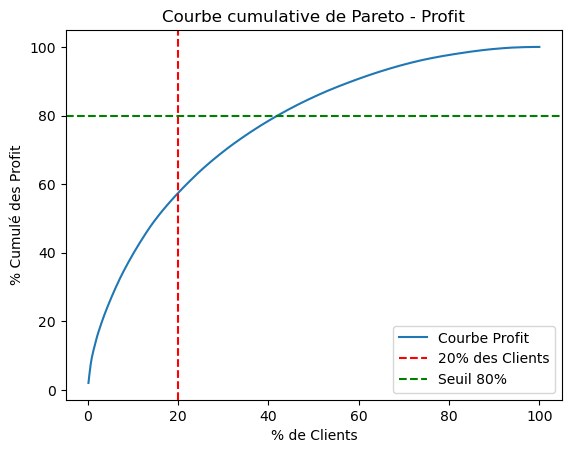

In [6]:
def check_pareto(df_target, column_metric):
    # Agrégation par client et tri décroissant
    client_data = df_target.groupby('Customer Name')[column_metric].sum().sort_values(ascending=False).reset_index()
    
    # Calculs cumulés
    client_data['Cum_Sum'] = client_data[column_metric].cumsum()
    client_data['Cum_Percentage'] = 100 * client_data['Cum_Sum'] / client_data[column_metric].sum()
    client_data['Client_Percentage'] = 100 * (client_data.index + 1) / len(client_data)
    
    # Trouver le % d'effet généré par 20% des clients
    effect_at_20 = np.interp(20, client_data['Client_Percentage'], client_data['Cum_Percentage'])
    print(f"Loi de Pareto pour {column_metric} : 20% des clients génèrent {effect_at_20:.2f}% des {column_metric}.")
    
    # Graphique
    plt.plot(client_data['Client_Percentage'], client_data['Cum_Percentage'], label=f'Courbe {column_metric}')
    plt.axvline(20, color='r', linestyle='--', label='20% des Clients')
    plt.axhline(80, color='g', linestyle='--', label='Seuil 80%')
    plt.title(f"Courbe cumulative de Pareto - {column_metric}")
    plt.xlabel("% de Clients")
    plt.ylabel(f"% Cumulé des {column_metric}")
    plt.legend()
    plt.show()

# Exécution pour les deux métriques
check_pareto(df, 'Sales')
check_pareto(df[df['Profit'] > 0], 'Profit') # Filtré sur les profits positifs pour éviter les biais de calcul


Recommandations pour la Stratégie MarketingD'après les résultats typiques de l'ensemble de données US Superstore 
:Priorisation des États :
Concentrez le budget sur la Californie et New York. 

Bien que la Californie génère un chiffre d'affaires plus élevé, New York affiche souvent une rentabilité (marge de profit) supérieure. Évitez le Texas ou l'Ohio qui affichent de lourdes pertes malgré de grosses ventes.Priorisation des Villes : Ciblez New York City et Los Angeles en priorité absolue. Attention à des villes comme Philadelphia ou Houston 
: elles font partie du Top 20 des ventes mais génèrent de fortes pertes à cause de remises trop agressives.
Ciblage Client (Pareto) : La loi des 80/20 se vérifie presque parfaitement (20% des clients font ~75-80% des ventes).

La stratégie marketing doit basculer vers un programme de fidélité VIP pour protéger ces 20% de clients à haute valeur, plutôt que de faire des campagnes de masse coûteuses.Souhaitez-vous que l'on développe le code pour analyser quelles catégories de produits causent les pertes dans les villes déficitaires ?